In [21]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer, StandardScaler

from dfply import *

# Import libraries
import tensorflow as tf
from tensorflow.keras import  regularizers, callbacks
from tensorflow.python.keras.utils.vis_utils import plot_model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, Concatenate, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# tf-explain for visual explanations
from tf_explain.core.gradients_inputs import GradientsInputs

import pydot, pyreadr

from scipy.stats import norm
from scipy import stats
import lime
from lime.lime_tabular import LimeTabularExplainer
from interpret.blackbox import LimeTabular
from interpret import show

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
from sklearn.metrics import classification_report

In [16]:
# --- Configuration ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [17]:
# Load the combined data containing both the gene expression data and metadata
df = pd.read_csv("unresampled_data_for_modeling.csv")
df

,seq_sample_id,age,BMI,scaled_pct_change,category,sequencing_depth,TSPAN6,DPM1,SCYL3,CFH,...,ENSG00000309174,ENSG00000309618,ENSG00000310376,CAST,ENSG00000310523,WASH7P,WASH9P,ENSG00000310533,sex_female,sex_male
0,FP11w0L,22.3,23.6,0.05,No_responder,1.51,3.85,30.23,8.50,15.33,...,2.95,5.89,1125.84,230.96,5.93,11.60,5.07,1.88,0,1
1,FP11w0R,22.3,23.6,0.07,Average_responder,1.51,4.72,27.63,9.59,19.16,...,3.75,4.72,1057.75,243.95,5.91,11.36,3.96,2.30,0,1
2,FP12w0L,21.3,22.8,0.21,Average_responder,1.51,5.48,32.51,6.23,15.13,...,2.91,7.09,614.65,143.06,7.21,7.53,7.33,2.78,1,0
3,FP12w0R,21.3,22.8,0.01,No_responder,1.51,5.88,28.35,5.72,16.30,...,2.41,10.94,584.76,142.61,7.23,15.26,9.02,1.10,1,0
4,FP13w0L,22.7,19.8,0.99,High_responder,1.51,5.59,34.57,4.74,9.17,...,2.29,6.95,724.77,158.42,3.87,16.90,13.56,5.87,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456,s891,54.0,21.8,0.42,Average_responder,2.35,3.94,18.93,7.06,10.28,...,4.78,1.79,12.13,131.02,17.86,29.32,28.00,3.93,1,0
457,s903,42.0,27.3,0.81,High_responder,2.35,4.37,18.69,7.91,15.64,...,3.86,2.01,12.21,126.66,13.64,27.64,18.58,1.20,1,0
458,s903,42.0,27.3,0.28,Average_responder,2.35,4.37,18.69,7.91,15.64,...,3.86,2.01,12.21,126.66,13.64,27.64,18.58,1.20,1,0
459,s96,48.0,27.7,0.35,Average_responder,2.35,4.69,25.65,7.67,13.27,...,1.94,1.73,37.61,151.40,15.83,24.10,27.72,3.25,0,1


Text(0, 0.5, 'Frequency')

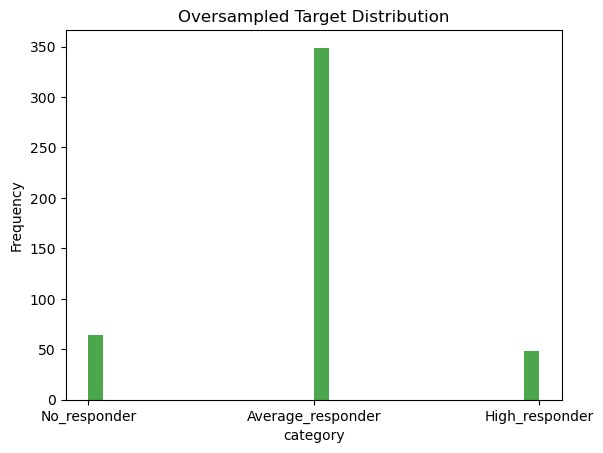

In [3]:

plt.hist(df['category'], bins=30, color='green', alpha=0.7)
plt.title('Oversampled Target Distribution')
plt.xlabel('category')
plt.ylabel('Frequency')

In [39]:
X = df.drop(["seq_sample_id", "scaled_pct_change", "category"], axis = 1)

y = df["category"]
#category_mapping = {'No_responder': 0, 'Average_responder': 1, 'High_responder': 2}
#y = y.map(category_mapping)
#y = np.array(y)


In [40]:

# Step 3: Apply SMOTE to oversample underrepresented classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)


Text(0, 0.5, 'Frequency')

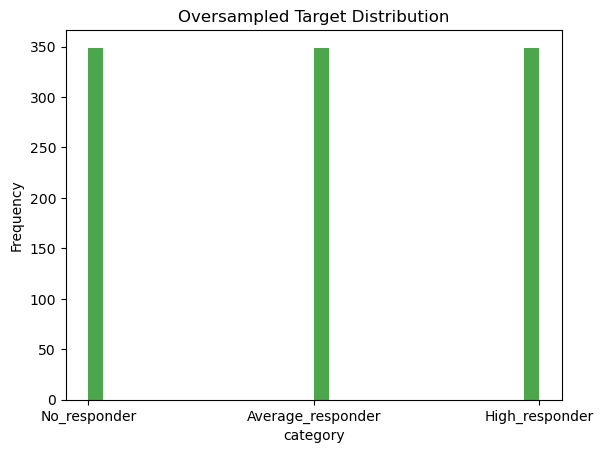

In [41]:

# Step 4: Visualize class distribution after SMOTE
plt.hist(y_resampled, bins=30, color='green', alpha=0.7)
plt.title('Oversampled Target Distribution')
plt.xlabel('category')
plt.ylabel('Frequency')

In [42]:
# Label encode the response parameter
category_mapping = {'No_responder': 0, 'Average_responder': 1, 'High_responder': 2}
y_resampled = np.array([category_mapping[label] for label in y_resampled])

array([0, 1, 1, ..., 0, 0, 0])

In [44]:
# --- Step 2: Correct Data Splitting and Scaling ---
# This is the most critical part for reliable model evaluation.
print("\nStep 2: Splitting and Scaling Data...")

# First, create the final test set (20% of data) which we won't touch until the very end.
X_train_full, X_test, y_train_full, y_test = train_test_split( X_resampled, y_resampled,  test_size=0.2, random_state=RANDOM_STATE)
# "stratify" enusres that the data distribution is maintained

# Second, create a validation set (20% of the remaining training data) for monitoring during training.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,  test_size=0.2, random_state=RANDOM_STATE
)




#  scale the data. Fit the scaler ONLY on the training data to prevent data leakage.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Training feature shape: {X_train_scaled.shape}")
print(f"Validation feature shape: {X_val_scaled.shape}")
print(f"Test feature shape: {X_test_scaled.shape}")



Step 2: Splitting and Scaling Data...
Training feature shape: (669, 11230)
Validation feature shape: (168, 11230)
Test feature shape: (210, 11230)


In [93]:
def build_multiclass_model(input_shape, num_classes):
    """Builds a sequential model for multi-class classification."""
    model = Sequential([
        Input(shape=input_shape),
 # Hidden Layer 1: Funnel architecture starts wider. L2 regularization added.
      
       Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        Dropout(0.5), # Using a slightly higher dropout rate
        
        
        # Hidden Layer 2
        Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        Dropout(0.4), # Using a slightly higher dropout rate

        
        # Hidden Layer 3
       Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
       Dropout(0.3),

        # Hidden Layer 4
        Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        Dropout(0.2),
        
         # Hidden Layer 5
        Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        Dense(num_classes, activation='softmax')  # Multi-class classification
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',  # cos labels are encoded as integers
                  metrics=[ "accuracy"])
    
    return model


In [94]:
# Get the input shape from the training data
input_shape = (X_train_scaled.shape[1],)
model = build_multiclass_model(input_shape, 3)
model.summary()


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_79 (Dense)                     │ (None, 1024)                │      11,500,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_49 (Dropout)                 │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_80 (Dense)                     │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_50 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_81 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_51 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_82 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_52 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_83 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_84 (Dense)                     │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,198,019 (46.53 MB)

 Trainable params: 12,198,019 (46.53 MB)

 Non-trainable params: 0 (0.00 B)

In [95]:

# --- Step 4: Train the Model with Advanced Callbacks ---
print("\nStep 4: Training the Model...")

# EarlyStopping to prevent overfitting by stopping when validation loss stops improving.
early_stopping = EarlyStopping(
    patience=15,          # How many epochs to wait after last improvement
    restore_best_weights=True # Restores model weights from the epoch with the best val_loss
)

# ReduceLROnPlateau to reduce the learning rate when a metric has stopped improving.
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,           # Factor by which the learning rate will be reduced. new_lr = lr * factor
    patience=5,           # Number of epochs with no improvement after which learning rate will be reduced.
    min_lr=1e-4           # Lower bound on the learning rate.
)
history = model.fit(
    X_train_scaled, y_train,
    epochs=200, # Train for more epochs; EarlyStopping will handle stopping.
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stopping, reduce_lr],
    verbose=1 # Set to 1 to see training progress
)



Step 4: Training the Model...
Epoch 1/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - accuracy: 0.3916 - loss: 7.7877 - val_accuracy: 0.4286 - val_loss: 5.6330 - learning_rate: 0.0010
Epoch 2/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.4113 - loss: 8.8917 - val_accuracy: 0.4821 - val_loss: 5.0336 - learning_rate: 0.0010
Epoch 3/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.3981 - loss: 7.3869 - val_accuracy: 0.4583 - val_loss: 4.8025 - learning_rate: 0.0010
Epoch 4/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.3725 - loss: 6.7769 - val_accuracy: 0.4762 - val_loss: 4.6906 - learning_rate: 0.0010
Epoch 5/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.4233 - loss: 5.9930 - val_accuracy: 0.4583 - val_loss: 4.6027 - learning_rate: 0.0010
Epoch 6/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.4639 - loss: 5.2624 - val_accuracy: 0.5298 - val_loss: 4.4632 - learning_rate: 0.0010
Epoch 7/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - 

In [72]:
# --- Step 5: Evaluate the Final Model ---
print("\nStep 5: Evaluating the Final Model on the Test Set...")

# Evaluate the model on the unseen test set to get a final, unbiased performance metric.
final_loss, final_mae = model.evaluate(X_test_scaled, y_test)
print(f"Final  loss: {final_loss:.4f}")
print(f"Final Test accuracy: {final_mae:.4f}")



Step 5: Evaluating the Final Model on the Test Set...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8848 - loss: 2.0201
Final Huber loss: 2.0053
Final Test MAE: 0.8810



Step 6: Visualizing Training History...


KeyError: 'mean_absolute_error'

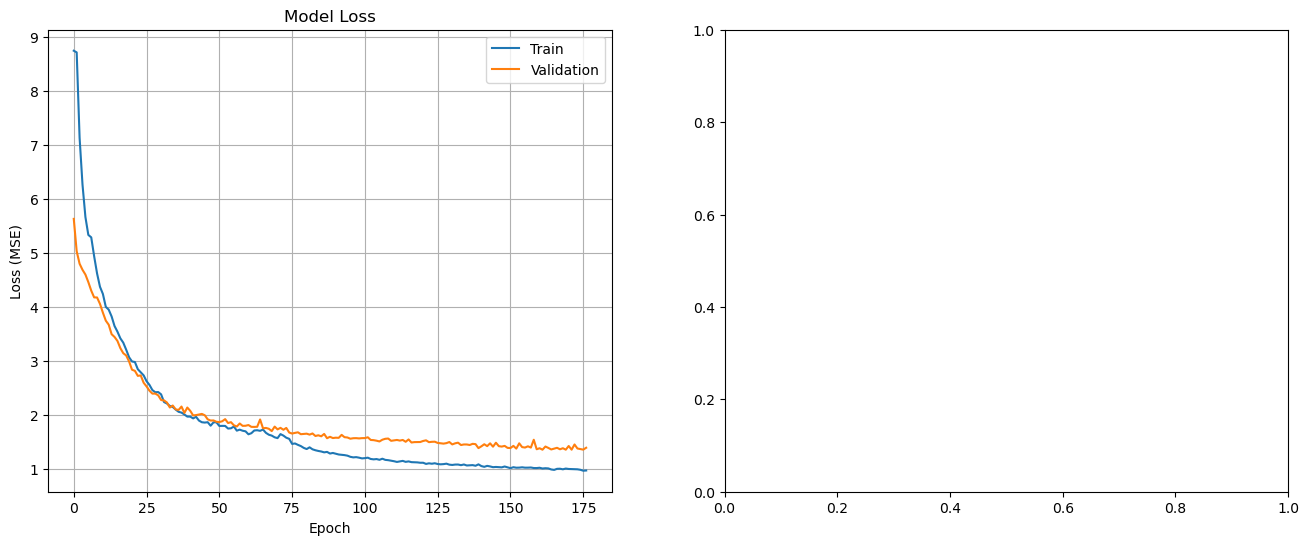

In [ ]:
# Generate predictions
y_pred_new = model.predict(X_test_scaled)

# Plot predicted vs actual values
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_new, alpha=0.5)
plt.plot([0, 1], [0, 1], 'r--') # Reference line y = x
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Values')
plt.show()
